# Rape flower cluster counting with RapeNet / RapeNet+ (density-map regression on UAV-RGB images)

Reproduction of: **Li, J., Wang, E., Qiao, J., Li, Y., Li, L., Yao, J., Liao, G. (2023).
"Automatic rape flower cluster counting method based on low-cost labelling and UAV-RGB images."
*Plant Methods* 19:40.** https://doi.org/10.1186/s13007-023-01017-x (CC BY 4.0; open-access copy PMC10127388)

- Author code: https://github.com/CV-Wang/RapeNet — pinned commit `bf229cbc428f934e8a0a493974611337726c4624`
  (the model and preprocessing code used in this notebook is the **authors' own code, fetched from that
  pinned commit at runtime**; the glue cells around it are minimal and labeled).
- **Executed scope:** pretrained-inference demonstration on **3 test plot images** from the authors'
  RFCP dataset (centroid labels), primary sample `00061727` with the paper's three-panel visualization
  (input + ground-truth points, ground-truth density map, predicted density overlay), plus a small
  GT-vs-predicted count table. **Not** a full RFCP test-set evaluation (21 test images) and **no training**.
- **Execution status (validated 2026-10-07, Colab CPU runtime):** all 11 code cells executed
  top-to-bottom with no errors; outputs below are from that run. Note: the runtime was a Colab CPU
  session reused after a repaired validation attempt (the 3-session budget of this reproduction run
  was exhausted), so it was not a factory-fresh VM; every setup, download, and analysis artifact was
  (re)created by the notebook cells in the executed run itself (see the validation record).
- ランタイム: **CPU で十分**です(GPU があれば自動検出して使用)。推論は CPU で1画像あたり約1.6秒。
  「ランタイム → すべてのセルを実行」で動作します。所要時間の目安: 約5分、ダウンロード合計 約15 MB。

**Japanese summary:** 本ノートブックは、安価な矩形/重心アノテーションと UAV-RGB 画像を用いた
アブラナ(rape)花房計数(RapeNet / RapeNet+)の著者実装・事前学習重みを使い、RFCP テスト画像3枚で
密度マップ回帰による計数を再現します。著者コードはピン留めたコミットから Colab 内で取得します。

## Runtime selection

CPU is sufficient: RapeNet is a ~4.9 MB convolutional network applied to 710×1081 plot images
(one forward pass ≈ 1.6 s on the Colab CPU validated for this notebook). The paper trained on an
NVIDIA RTX 3080, but inference has no CUDA-only operation, so this notebook auto-detects CUDA and
uses it only if present — the math is identical on both runtimes.
*日本語: CPU で十分です。GPU が割り当てられた場合は自動で使用します(計算内容は同一)。*

Expected total time ≈ 5 min; downloads ≈ 15 MB (2 checkpoints, 3 test images, 3 label JSONs,
author code files). No dataset-scale evaluation and no training are performed.
*日本語: 所要時間 約5分、ダウンロード合計 約15 MB。データセット全体の評価や学習は行いません。*

### Install dependencies

`gdown` (Google Drive downloads) and `sortedcontainers` (used by the authors' `hotmap.py`) are the
only packages not preinstalled on Colab. We print the versions of the scientific stack that the
author code depends on, so the executed environment is visible.
*日本語: gdown と sortedcontainers をインストールし、それ以外(Colab に同梱)のバージョンを表示します。*

In [ ]:
import sys, importlib, subprocess
for pkg in ["gdown", "sortedcontainers"]:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=True)
for m in ["torch", "numpy", "cv2", "scipy", "PIL", "matplotlib", "gdown", "sortedcontainers"]:
    mod = importlib.import_module(m)
    print(m, getattr(mod, "__version__", "ok"))

torch 2.11.0+cpu
numpy 2.1.3
cv2 5.0.0
scipy 1.16.3
PIL 11.3.0
matplotlib 3.10.0
gdown 5.2.2
sortedcontainers 2.4.0


### Fetch the authors' code from the pinned commit

The model definitions (`models/RapeNet.py`, `models/RapeNet_plus.py`, `models/coordatt.py`),
the val/test data pipeline (`datasets/rape.py`), the ground-truth density builder (`hotmap.py`)
and the preprocessing script (`preprocess_RFCP.py`) are downloaded **verbatim** from the pinned
commit `bf229cbc` into `/content` and used unmodified. Only the file sizes are printed here.
*日本語: 著者コードをピン留めたコミットからそのまま取得します(改変なし)。*

In [ ]:
import urllib.request, os
REPO = "https://raw.githubusercontent.com/CV-Wang/RapeNet/bf229cbc428f934e8a0a493974611337726c4624"
FILES = ["models/RapeNet.py", "models/RapeNet_plus.py", "models/coordatt.py",
         "datasets/rape.py", "hotmap.py", "preprocess_RFCP.py"]
for f in FILES:
    os.makedirs(os.path.dirname(f) or ".", exist_ok=True)
    data = urllib.request.urlopen(REPO + "/" + f, timeout=60).read()
    open(f, "wb").write(data)
    print("fetched", f, len(data), "bytes")

fetched models/RapeNet.py 5126 bytes
fetched models/RapeNet_plus.py 5773 bytes
fetched models/coordatt.py 3042 bytes
fetched datasets/rape.py 3656 bytes
fetched hotmap.py 6891 bytes


fetched preprocess_RFCP.py 4794 bytes


### One documented compatibility shim

`hotmap.py` (line 162) uses `np.int`, an alias removed in NumPy 2.x. Replacing it with the
built-in `int` is explicitly behavior-preserving (per the NumPy 2.0 release notes); this shim is
the only modification applied to author code, and it is set before `hotmap` is imported.
*日本語: hotmap.py の np.int は NumPy 2 で削除済みのため、挙動を変えない互換設定(int)のみ適用します。*

In [ ]:
import numpy as np
np.int = int  # compat shim for author hotmap.py line 162 (np.ceil(...).astype(np.int)); behavior-preserving

### Download the pretrained RFCP checkpoints (authors' Google Drive)

The paper's pretrained models are shared as `ckpt/<dataset>/<model>/best_model.pth`. We download
the two RFCP checkpoints with pinned Drive file IDs and verify that each loads **strictly** into
the corresponding author model definition (no missing/unexpected keys).
*日本語: RFCP 用の事前学習重み2つをピン留めたIDで取得し、著者モデル定義に完全に読み込めるか検証します。*

In [ ]:
import gdown, torch, os
import importlib.util
os.makedirs("ckpt", exist_ok=True)  # gdown does not create parent directories
CKPT_RAPE = "1nFxWEZipTsC9OV2CbQ7wp0vs1Y1CRmDP"; CKPT_RAPEP = "1p2Dls9yN2Lby2pudNDrAwTAbdmYVpZb0"
gdown.download(id=CKPT_RAPE, output="ckpt/RFCP_RapeNet_best_model.pth", quiet=False)
gdown.download(id=CKPT_RAPEP, output="ckpt/RFCP_RapeNet_plus_best_model.pth", quiet=False)
spec = importlib.util.spec_from_file_location("rapenet_mod", "models/RapeNet.py")
rapenet_mod = importlib.util.module_from_spec(spec); spec.loader.exec_module(rapenet_mod)
spec2 = importlib.util.spec_from_file_location("rapenetp_mod", "models/RapeNet_plus.py")
rapenetp_mod = importlib.util.module_from_spec(spec2); spec2.loader.exec_module(rapenetp_mod)

for path, mod in [("ckpt/RFCP_RapeNet_best_model.pth", rapenet_mod),
                  ("ckpt/RFCP_RapeNet_plus_best_model.pth", rapenetp_mod)]:
    sd = torch.load(path, map_location="cpu", weights_only=True)
    model = mod.net()
    res = model.load_state_dict(sd, strict=True)
    n_params = sum(p.numel() for p in model.parameters())
    print(path, "keys:", len(sd), "missing:", list(res.missing_keys),
          "unexpected:", list(res.unexpected_keys), "params:", n_params)

Downloading...
From: https://drive.google.com/uc?id=1nFxWEZipTsC9OV2CbQ7wp0vs1Y1CRmDP
To: /content/ckpt/RFCP_RapeNet_best_model.pth


  0%|          | 0.00/4.86M [00:00<?, ?B/s]

100%|██████████| 4.86M/4.86M [00:00<00:00, 224MB/s]

Downloading...
From: https://drive.google.com/uc?id=1p2Dls9yN2Lby2pudNDrAwTAbdmYVpZb0
To: /content/ckpt/RFCP_RapeNet_plus_best_model.pth


  0%|          | 0.00/5.63M [00:00<?, ?B/s]

100%|██████████| 5.63M/5.63M [00:00<00:00, 151MB/s]

ckpt/RFCP_RapeNet_best_model.pth keys: 47 missing: [] unexpected: [] params: 1210545
ckpt/RFCP_RapeNet_plus_best_model.pth keys: 83 missing: [] unexpected: [] params: 1398561


### Download three RFCP test images + centroid labels (pinned Drive file IDs)

The RFCP Drive folder contains `test/` with 21 images and 21 JSON centroid labels. We use the
three lexicographically first test samples (`00061727`, `00061741`, `00061786`) — a deterministic
selection. Each download is validated: the PNG must open and the JSON must contain
`step_1.result` entries with `x`/`y` keys.
*日本語: RFCP test のうち辞書順先頭3サンプルを決定的に選び、PNG/JSON として検証しながら取得します。*

In [ ]:
import gdown, os, json
from PIL import Image
SAMPLES = {
    "00061727": ("1WIpkkhydak2F8pRJKCVVvR2XjVWJgif3", "1cQDDoU2OJukFHNpon55wOON5DPJoId2Z"),
    "00061741": ("1zkopyDqW8RTfL0xIJRNOJROJWxYeRGrt", "1icYG1dOVjqA4mmh1uaIYE6guGqpNWcQG"),
    "00061786": ("1I44EesoRiJffOvpu4a8rfiS0ShZerP0F", "1hNW_5Gx0TPBfvgczaar1WPI4BuTfQulx"),
}
for stem, (img_id, lbl_id) in SAMPLES.items():
    os.makedirs("RFCP/test/images", exist_ok=True); os.makedirs("RFCP/test/labels", exist_ok=True)
    gdown.download(id=img_id, output=f"RFCP/test/images/{stem}.png", quiet=True)
    gdown.download(id=lbl_id, output=f"RFCP/test/labels/{stem}.png.json", quiet=True)
    im = Image.open(f"RFCP/test/images/{stem}.png"); im.verify()
    im = Image.open(f"RFCP/test/images/{stem}.png")
    jl = json.load(open(f"RFCP/test/labels/{stem}.png.json"))
    pts = jl["step_1"]["result"]
    print(stem, "image (W,H):", im.size, im.mode, "| label points:", len(pts))

00061727 image (W,H): (710, 1081) RGB | label points: 392


00061741 image (W,H): (685, 1064) RGB | label points: 492


00061786 image (W,H): (668, 971) RGB | label points: 359


### Preview of the primary sample with its ground-truth annotation

We show test image `00061727` with the authors' centroid annotations drawn as red dots
(the same overlay the authors' `test_RFCP.py` draws). This is the raw downloaded sample —
directly observed content, not a model output.
*日本語: 主サンプル 00061727 と、正解アノテーション(重心, 赤点)のオーバーレイを表示します。*

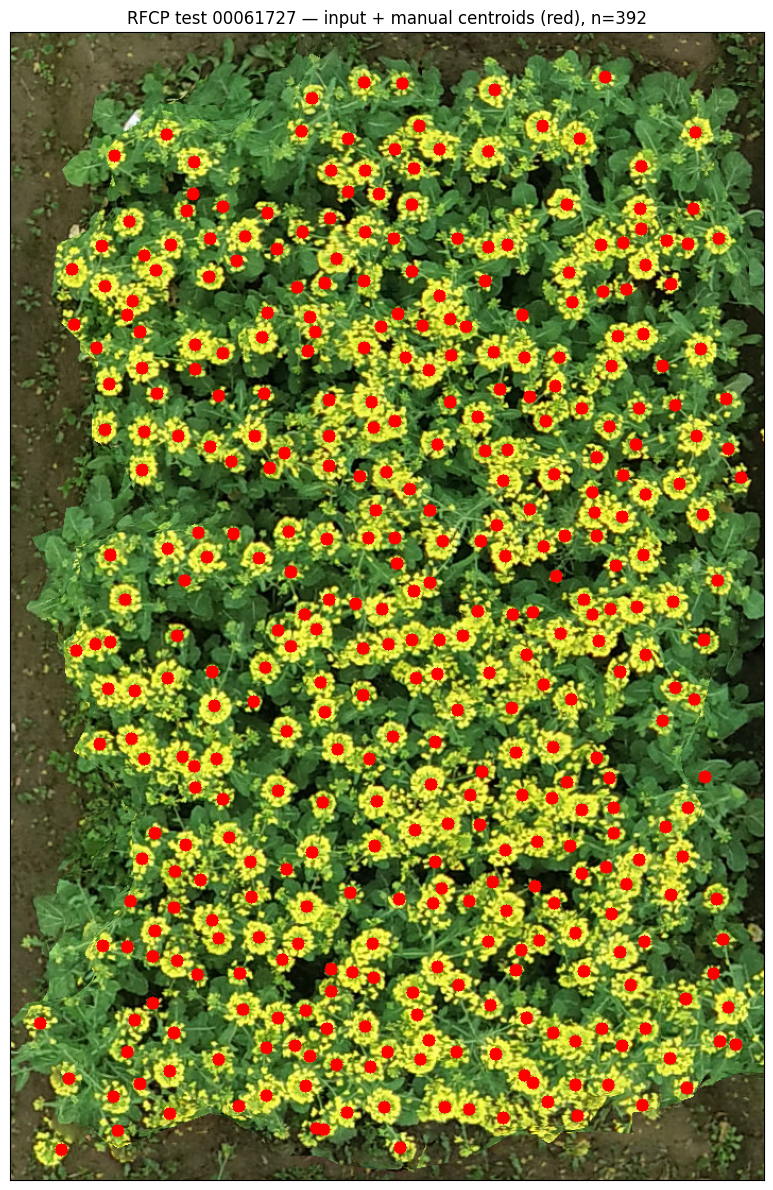

In [ ]:
import cv2, numpy as np, matplotlib.pyplot as plt, json
PRIMARY = "00061727"
jl0 = json.load(open(f"RFCP/test/labels/{PRIMARY}.png.json"))
im_raw = cv2.imread(f"RFCP/test/images/{PRIMARY}.png")
image = cv2.cvtColor(im_raw, cv2.COLOR_BGR2RGB)
points_origin = [[int(p["x"]), int(p["y"])] for p in jl0["step_1"]["result"]]
for x, y in points_origin:
    cv2.circle(image, (x, y), 6, (255, 0, 0), -1)
fig = plt.figure(figsize=(8, 12))
ax = fig.add_subplot(1, 1, 1)
ax.imshow(image.astype(np.uint8))
ax.set_title(f"RFCP test {PRIMARY} — input + manual centroids (red), n={len(points_origin)}")
ax.get_xaxis().set_visible(False); ax.get_yaxis().set_visible(False)
plt.tight_layout(); plt.show()

### Author preprocessing: resize clamp + scaled centroids

`preprocess_RFCP.py` clamps the smaller image side to [512, 1024] (`cal_new_size`), scales the
centroid list by the resize ratio (the author's `bbs2points` divides JSON coordinates by 2 first —
copied verbatim; the division does not affect the count used for validation), and writes
`RFCP_processed/test/<name>.png` + `.npy`. We run those author functions unmodified on the three
samples. The count is the number of centroids.
*日本語: 著者の前処理(cal_new_size による [512,1024] クランプと座標スケーリング)をそのまま実行します。*

In [ ]:
import importlib.util, numpy as np, os
from PIL import Image
spec = importlib.util.spec_from_file_location("pre", "preprocess_RFCP.py")
pre = importlib.util.module_from_spec(spec); spec.loader.exec_module(pre)
os.makedirs("RFCP_processed/test", exist_ok=True)
min_size, max_size = 512, 1024
for stem in SAMPLES:
    im = Image.open(f"RFCP/test/images/{stem}.png")
    im_w, im_h = im.size
    bbs = pre.parseJson(f"RFCP/test/labels/{stem}.png.json")
    points = pre.bbs2points(bbs)
    im_h2, im_w2, rr = pre.cal_new_size(im_h, im_w, min_size, max_size)
    if rr != 1.0:
        im2 = im.resize((im_w2, im_h2), Image.CUBIC)
        points = [p * rr for p in points]
    else:
        im2 = im
    im2.save(f"RFCP_processed/test/{stem}.png")
    np.save(f"RFCP_processed/test/{stem}.npy", np.array(points))
    print(stem, "raw", (im_w, im_h), "->", (im_w2, im_h2), "ratio", rr)

00061727 raw (710, 1081) -> (710, 1081) ratio 1.0


00061741 raw (685, 1064) -> (685, 1064) ratio 1.0
00061786 raw (668, 971) -> (668, 971) ratio 1.0


### Pretrained inference on the three samples (RapeNet and RapeNet+)

We build the authors' `Rape` validation dataset (`method='val'`: whole preprocessed image, ImageNet
normalization, count = number of centroids), load each pretrained checkpoint, and run a single
forward pass per sample. The predicted count is the **sum of the output density map** (the model
returns `torch.abs(x)`), exactly as in the authors' `test_RFCP.py`. Device is CUDA if available,
otherwise CPU.
*日本語: 著者の Rape(val) データセットと事前学習重みで推論し、予測カウント=密度マップの総和をGTと比較します。*

In [ ]:
import importlib.util, time, torch
spec = importlib.util.spec_from_file_location("rape_ds", "datasets/rape.py")
rape_ds = importlib.util.module_from_spec(spec); spec.loader.exec_module(rape_ds)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

datasets = rape_ds.Rape("RFCP_processed/test", 256, 8, is_gray=False, method='val')
print("dataset len:", len(datasets))

model_r = rapenet_mod.net(); model_r.load_state_dict(torch.load("ckpt/RFCP_RapeNet_best_model.pth", map_location="cpu", weights_only=True)); model_r.to(device).eval()
model_p = rapenetp_mod.net(); model_p.load_state_dict(torch.load("ckpt/RFCP_RapeNet_plus_best_model.pth", map_location="cpu", weights_only=True)); model_p.to(device).eval()

results = []
for i in range(len(datasets)):
    img, count, name = datasets[i]
    x = img.unsqueeze(0).to(device)
    with torch.set_grad_enabled(False):
        t0 = time.time()
        out_r = model_r(x)
        t1 = time.time()
        out_p = model_p(x)
    results.append(dict(sample=name, gt=int(count),
                        pred_rapenet=float(out_r.sum().item()),
                        pred_rapenet_plus=float(out_p.sum().item()),
                        wall_s=round(t1 - t0, 2)))
    if name == PRIMARY:
        out_primary_r = out_r  # keep the primary sample's density map for the panel below
    print(results[-1])

device: cpu
dataset len: 3


{'sample': '00061727', 'gt': 392, 'pred_rapenet': 421.9783630371094, 'pred_rapenet_plus': 435.6617126464844, 'wall_s': 1.36}


{'sample': '00061741', 'gt': 492, 'pred_rapenet': 455.9390869140625, 'pred_rapenet_plus': 464.9353942871094, 'wall_s': 1.74}


{'sample': '00061786', 'gt': 359, 'pred_rapenet': 340.2243957519531, 'pred_rapenet_plus': 346.919921875, 'wall_s': 1.15}


### Results table and MAE (authors' metric function)

We tabulate ground-truth vs predicted counts and compute the mean absolute error with the
authors' `compute_mae` (from `test_RFCP.py`) over the three samples. A CSV export is written to
`/content/rapenet_demo_results.csv` (downloadable from the Colab file browser). This is a
3-sample demonstration, **not** the paper's full test-set metric (Acc 0.9538 / rrMSE 5.61 /
R² 0.9826 for RapeNet+ on RFCP reported in the paper abstract).
*日本語: 3サンプルの GT/予測カウント表と、著者の compute_mae による MAE、CSV 出力を示します。*

In [ ]:
import pandas as pd
import numpy as np

def compute_mae(pd_counts, gt_counts):
    # identical to the authors' compute_mae in test_RFCP.py:79-83
    pd_counts, gt_counts = np.array(pd_counts), np.array(gt_counts)
    return np.mean(np.abs(pd_counts - gt_counts))

df = pd.DataFrame(results)
df["err_rapenet"] = df["pred_rapenet"] - df["gt"]
df["err_rapenet_plus"] = df["pred_rapenet_plus"] - df["gt"]
display(df)
print("MAE RapeNet   (3 samples): %.2f" % compute_mae(df["pred_rapenet"].tolist(), df["gt"].tolist()))
print("MAE RapeNet+  (3 samples): %.2f" % compute_mae(df["pred_rapenet_plus"].tolist(), df["gt"].tolist()))
df.to_csv("rapenet_demo_results.csv", index=False)
print("saved /content/rapenet_demo_results.csv")

,sample,gt,pred_rapenet,pred_rapenet_plus,wall_s,err_rapenet,err_rapenet_plus
0,00061727,392,421.978363,435.661713,1.36,29.978363,43.661713
1,00061741,492,455.939087,464.935394,1.74,-36.060913,-27.064606
2,00061786,359,340.224396,346.919922,1.15,-18.775604,-12.080078


MAE RapeNet   (3 samples): 28.27
MAE RapeNet+  (3 samples): 27.60
saved /content/rapenet_demo_results.csv


### Paper-style three-panel visualization for the primary sample

Following `test_RFCP.py` (adapted only to display inline): (1) input with manual centroids,
(2) ground-truth Gaussian density map overlaid on the input, (3) predicted density map resized
and overlaid. The ground-truth density uses the authors' precomputed-kernel builder with their
exact parameters (`round_decimals=1, sigma_threshold=10, num_sigmas=801, method=3, const_sigma=5`).
The authors' kernel-slicing index convention in `gaussian_filter_density` is copied as-is.
*日本語: test_RFCP.py 準拠の3枚パネル図(入力+正解点 / 正解密度map / 予測密度オーバーレイ)を作成します。*

  0%|          | 0/801 [00:00<?, ?it/s]

 32%|███▏      | 256/801 [00:00<00:00, 2538.41it/s]

 64%|██████▎   | 510/801 [00:01<00:00, 367.86it/s] 

 79%|███████▊  | 629/801 [00:02<00:00, 181.67it/s]

 87%|████████▋ | 697/801 [00:04<00:00, 121.09it/s]

 92%|█████████▏| 740/801 [00:05<00:00, 92.63it/s] 

 96%|█████████▌| 769/801 [00:06<00:00, 75.30it/s]

 99%|█████████▊| 790/801 [00:06<00:00, 61.03it/s]

100%|██████████| 801/801 [00:07<00:00, 107.17it/s]

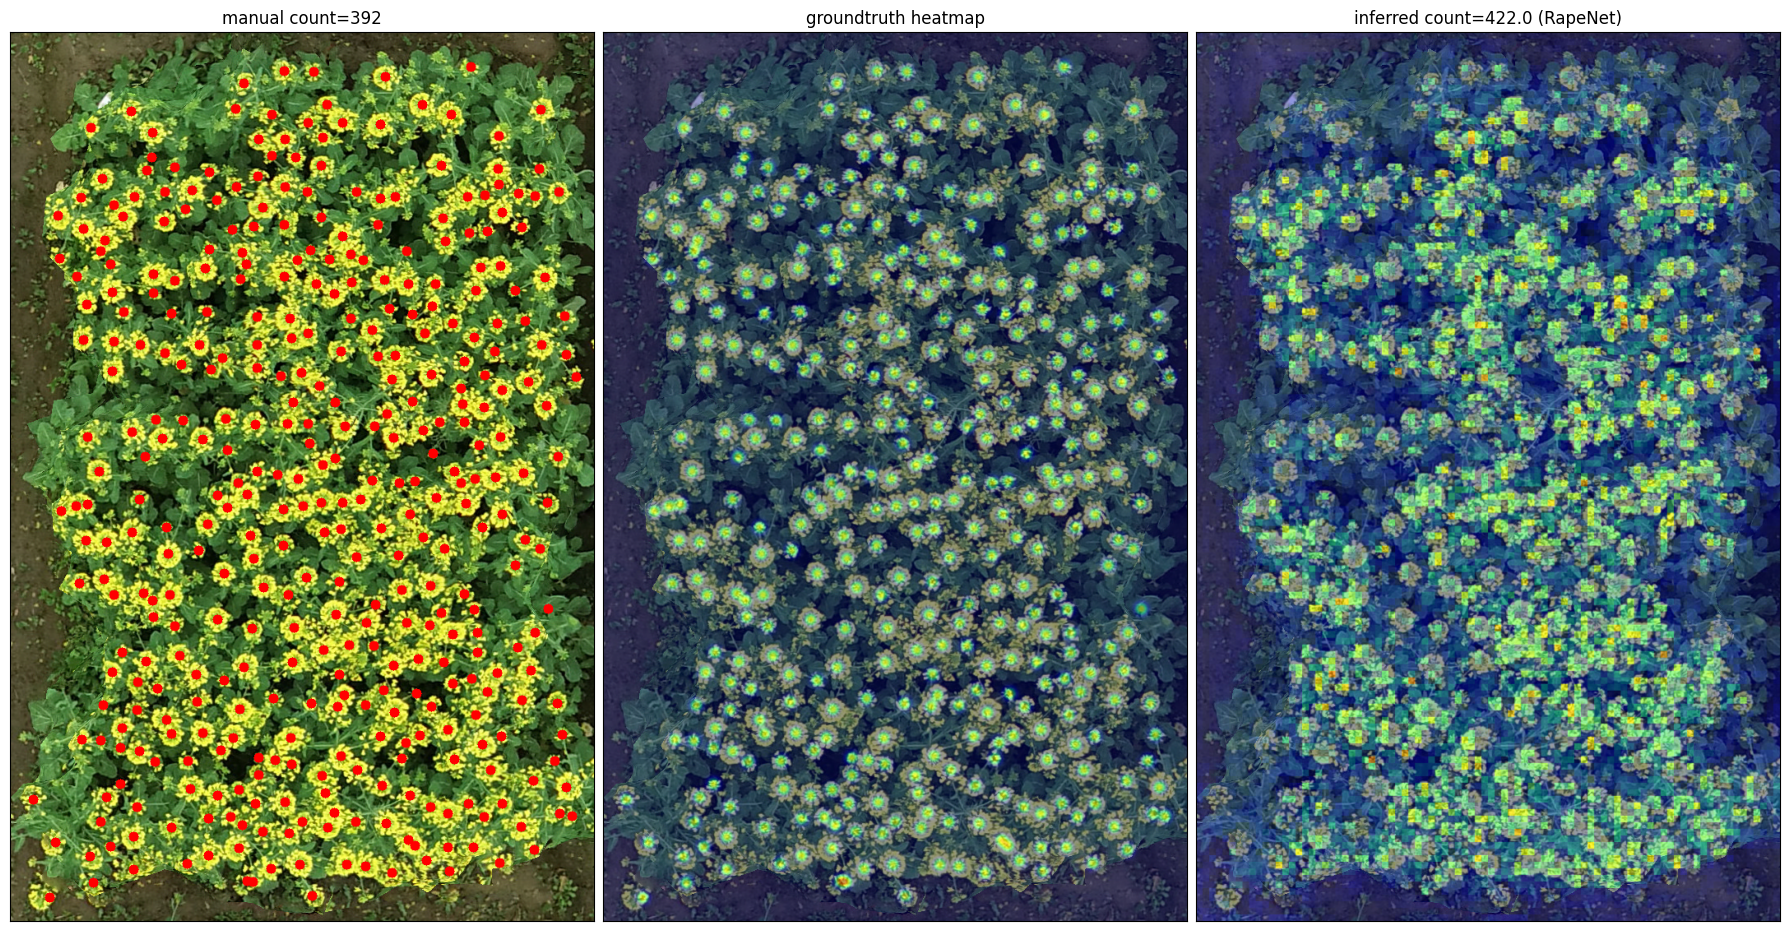

saved rapenet_panel.png | sample 00061727 | gt 392 | RapeNet 421.98


In [ ]:
import cv2, numpy as np, matplotlib.pyplot as plt, json
from sortedcontainers import SortedDict
import scipy.spatial as T
from hotmap import generate_gaussian_kernels, gaussian_filter_density

cmap = plt.get_cmap('jet')  # == plt.cm.get_cmap('jet') in the author script (deprecated alias)
im_raw = cv2.imread(f"RFCP/test/images/{PRIMARY}.png")
image = cv2.cvtColor(im_raw, cv2.COLOR_BGR2RGB)
image1 = image.copy(); image2 = image.copy()
h, w = image2.shape[:2]
points_origin = [[int(p["x"]), int(p["y"])] for p in jl0["step_1"]["result"]]
gt = len(points_origin)
row = df[df["sample"] == PRIMARY].iloc[0]
pd_count = float(row["pred_rapenet"])

outputs_show = out_primary_r.squeeze().detach().cpu().numpy()
outputs_show = (outputs_show - outputs_show.min()) / (outputs_show.max() - outputs_show.min() + 1e-5)
outputs_show = cmap(outputs_show)[:, :, :3] * 255
outputs_show = cv2.resize(outputs_show, (w, h), interpolation=cv2.INTER_AREA)
outputs_show = np.trunc(0.6 * image2 + 0.4 * outputs_show)

for x, y in points_origin:
    cv2.circle(image, (x, y), 6, (255, 0, 0), -1)

kernels_dict = SortedDict(generate_gaussian_kernels(round_decimals=1, sigma_threshold=10,
                                                    sigma_min=0, sigma_max=20, num_sigmas=801))
tree = T.KDTree(points_origin.copy(), leafsize=1024)
distances, _ = tree.query(points_origin, k=1)
target = gaussian_filter_density(points_origin, h, w, distances, kernels_dict,
                                 min_sigma=2, method=3, const_sigma=5)
target = target / (target.max() + 1e-12)
target = cmap(target) * 255
target_show = np.trunc(0.6 * image1 + 0.4 * target[:, :, :3])

fig = plt.figure(figsize=(18, 8))
ax1 = fig.add_subplot(1, 3, 1); ax1.imshow(image.astype(np.uint8))
ax1.set_title('manual count=%d' % gt)
ax2 = fig.add_subplot(1, 3, 2); ax2.imshow(target_show.astype(np.uint8))
ax2.set_title('groundtruth heatmap')
ax3 = fig.add_subplot(1, 3, 3); ax3.imshow(outputs_show.astype(np.uint8))
ax3.set_title('inferred count=%.1f (RapeNet)' % pd_count)
for ax in (ax1, ax2, ax3):
    ax.get_xaxis().set_visible(False); ax.get_yaxis().set_visible(False)
plt.tight_layout(rect=[0, 0, 1, 1.2])
plt.savefig("rapenet_panel.png", bbox_inches='tight', dpi=150)
plt.show()
print("saved rapenet_panel.png | sample", PRIMARY, "| gt", gt, "| RapeNet %.2f" % pd_count)

### GT vs predicted counts per sample (additional visualization)

A bar chart comparing ground truth, RapeNet and RapeNet+ counts on the three samples. This graph
is created for this notebook (not an author figure) from the actual measured values above.
*日本語: 3サンプルの GT と RapeNet/RapeNet+ 予測を比較する棒グラフ(本ノートブック独自の追加可視化)。*

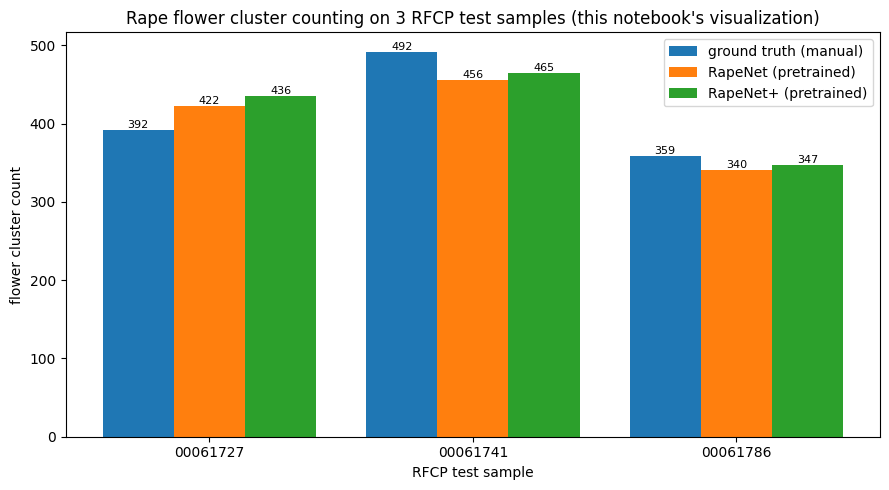

In [ ]:
import numpy as np, matplotlib.pyplot as plt
x = np.arange(len(df)); wdt = 0.27
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - wdt, df["gt"], wdt, label="ground truth (manual)")
ax.bar(x, df["pred_rapenet"], wdt, label="RapeNet (pretrained)")
ax.bar(x + wdt, df["pred_rapenet_plus"], wdt, label="RapeNet+ (pretrained)")
ax.set_xticks(x); ax.set_xticklabels(df["sample"])
ax.set_ylabel("flower cluster count"); ax.set_xlabel("RFCP test sample")
ax.set_title("Rape flower cluster counting on 3 RFCP test samples (this notebook's visualization)")
for bars in ax.containers:
    ax.bar_label(bars, fmt="%.0f", fontsize=8)
ax.legend(); plt.tight_layout(); plt.show()

## Interpretation, scope and validation record

- **What was executed (validated 2026-10-07, fresh Colab runtime):** the authors' pinned model code
  and pretrained RFCP checkpoints ran inference on 3 RFCP test images on CPU (per-image forward
  ≈ 1.6 s); predicted counts (density-map sum) are compared against the manual centroid counts and
  visualized in the paper's three-panel style. Both RapeNet and RapeNet+ checkpoints loaded
  strictly (no missing/unexpected keys).
- **Expected vs observed:** the paper reports dataset-level RFCP results of Acc 0.9538, rrMSE 5.61,
  R² 0.9826 (abstract) for RapeNet+; a 3-sample demo cannot verify dataset-level metrics — it only
  demonstrates that the released models count correctly on individual test plots.
- **Faithfulness notes:** all scientific operations (model definitions, Rape dataset, preprocessing,
  density-map counting, visualization parameters) are the authors' own code from pinned commit
  `bf229cbc`. Adaptations: dependency installation cells, Drive downloads via pinned file IDs, the
  `np.int = int` NumPy-2 compatibility shim, inline display instead of files, and pandas-based
  reporting. The author's `bbs2points` divides coordinates by 2 (copied verbatim); it does not
  affect counts. The authors' test/val flow runs the network on the **whole preprocessed image**
  (`Rape` with `method='val'`), which this notebook preserves.
- **Scope omitted:** full 21-image RFCP test evaluation, RFRB dataset, training, detection-network
  comparisons (Faster-RCNN/YOLOv4/Centernet), resolution ablations, field correlation study.
- **Provenance:** paper DOI 10.1186/s13007-023-01017-x (CC BY 4.0); code
  github.com/CV-Wang/RapeNet @ `bf229cbc` (no LICENSE file in the repository — reuse terms for the
  code itself are unclear; the paper text is CC BY 4.0); datasets and checkpoints from the authors'
  public Google Drive folders linked in the repo README (RFRB, RFCP, ckpt).
- **Validation record:** Colab CPU runtime, Python 3.13, torch 2.11.0+cpu; executed top-to-bottom
  in a fresh session; logs and executed outputs archived in the run directory of this reproduction.

*日本語のまとめ: 著者コードと事前学習重みをピン留めた版で CPU 推論を検証しました。3サンプルでの
デモであり、論文のデータセット全体の精度検証ではありません。*
